In [535]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import numpy as np
import pandas as pd

In [536]:
diagrams_path = './figures/'

In [537]:
plt.rcParams.update({'font.size': 14})

In [538]:
boss_rand_df = pd.read_csv('./experiment-results/boss-rand-results.csv')
boss_bixi_df = pd.read_csv('./experiment-results/boss-bixi-results.csv')
competition_rand_df = pd.read_csv('./experiment-results/competition-rand-results.csv')
competition_bixi_df = pd.read_csv('./experiment-results/competition-bixi-results.csv')

rand_df = pd.merge(boss_rand_df, competition_rand_df, left_on='table name', right_on='table name')
bixi_df = pd.merge(boss_bixi_df, competition_bixi_df, left_on='table name', right_on='table name')

print(rand_df)
print()
print(bixi_df)

  table name  boss data in  boss round trip  boss materialise columns  \
0       64 b         67224           117285                    129121   
1       1 mb         68075           321523                    334894   
2      10 mb         68133          2607503                   2606172   
3     100 mb         68339         13342084                  13353095   
4       1 gb         76411        151775432                 145692351   
5       2 gb         85038        265504523                 288523975   

   boss materialise matrix  boss matrix vector product  \
0                   166052                      204639   
1                   260349                      783442   
2                  2033577                     2835154   
3                 79228307                    41687670   
4                739076365                   432153357   
5               1542633549                   825659491   

   boss matrix matrix product  pandas data in  duckdb data in  sqlite data in  
0

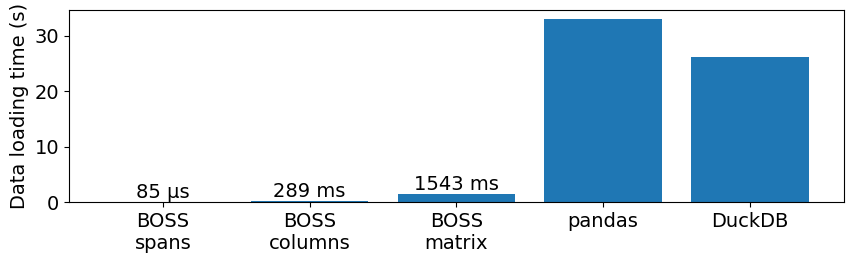

In [539]:
vendor_tasks = ['boss data in', 'boss materialise columns', 'boss materialise matrix', 'pandas data in', 'duckdb data in']
vendors = ['BOSS\nspans', 'BOSS\ncolumns', 'BOSS\nmatrix', 'pandas', 'DuckDB']
times = [rand_df.loc[5, x] / (10 ** 9) for x in vendor_tasks]

fig, ax = plt.subplots()
bar_container = ax.bar(vendors, times)
ax.set(ylabel='Data loading time (s)', 
       # title='data loading time for 2 GB table'
      )
# ax.bar_label(bar_container, fmt=lambda x: f'{x * (10 ** 3):.1f} ms')

rect = bar_container[0]
ax.annotate(f'{(rect.get_height() * (10 ** 6)):.0f} μs',
            xy=(rect.get_x() + rect.get_width() / 2, rect.get_y() + rect.get_height()),
            xytext=(0, 0),
            textcoords='offset points',
            ha='center', va='bottom')

rect = bar_container[1]
ax.annotate(f'{(rect.get_height() * (10 ** 3)):.0f} ms',
            xy=(rect.get_x() + rect.get_width() / 2, rect.get_y() + rect.get_height()),
            xytext=(0, 0),
            textcoords='offset points',
            ha='center', va='bottom')

rect = bar_container[2]
ax.annotate(f'{(rect.get_height() * (10 ** 3)):.0f} ms',
            xy=(rect.get_x() + rect.get_width() / 2, rect.get_y() + rect.get_height()),
            xytext=(0, 0),
            textcoords='offset points',
            ha='center', va='bottom')

figwidth = 10
aspect_ratio = (1 / 4)
fig.set_figwidth(figwidth)
fig.set_figheight(figwidth * aspect_ratio)

plt.savefig(f'{diagrams_path}data-loading-2gb.svg', bbox_inches='tight', dpi=600)
plt.show()

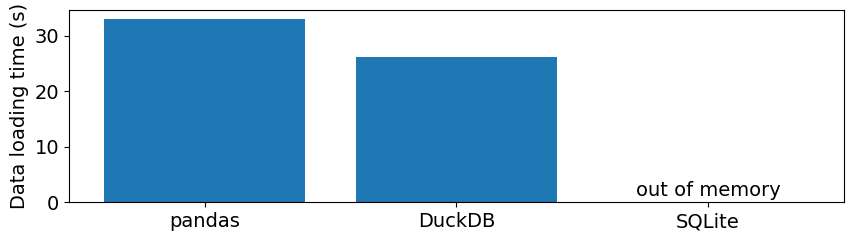

In [540]:
vendors = ['pandas', 'duckdb', 'sqlite']
vendor_tasks = [f'{x} data in' for x in vendors]
vendors = ['pandas', 'DuckDB', 'SQLite']
times = [rand_df.loc[5, x] / (10 ** 9) for x in vendor_tasks]
times[2] = 0

fig, ax = plt.subplots()
bar_container = ax.bar(vendors, times)
ax.set(ylabel='Data loading time (s)', 
       # title='data loading time for 2gb table'
      )

rect = bar_container[2]
ax.annotate(f'out of memory',
            xy=(rect.get_x() + rect.get_width() / 2, rect.get_y() + rect.get_height() + 0.5),
            xytext=(0, 0),
            textcoords='offset points',
            ha='center', va='bottom')

figwidth = 10
aspect_ratio = (1 / 4)
fig.set_figwidth(figwidth)
fig.set_figheight(figwidth * aspect_ratio)

plt.savefig(f'{diagrams_path}data-loading-2gb-short.svg', bbox_inches='tight', dpi=600)
plt.show()

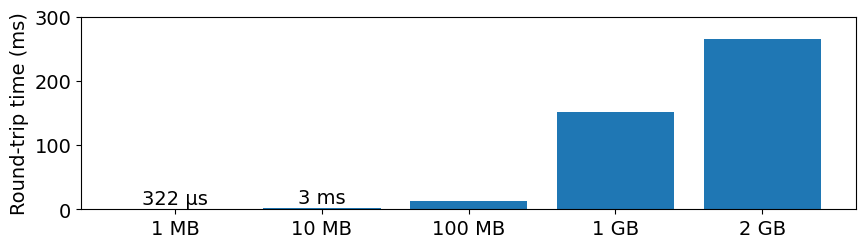

In [541]:
times = rand_df.loc[1:, 'boss round trip'] / (10 ** 6)
table_names = rand_df.loc[1:, 'table name']
table_names = [
    '1 MB',
    '10 MB',
    '100 MB',
    '1 GB',
    '2 GB',
]

fig, ax = plt.subplots()
bar_container = ax.bar(table_names, times)
ax.set(ylabel='Round-trip time (ms)', 
       # title='round trip time: boss -> python -> boss'
      )

rect = bar_container[0]
ax.annotate(f'{(rect.get_height() * (10 ** 3)):.0f} μs',
            xy=(rect.get_x() + rect.get_width() / 2, rect.get_y() + rect.get_height() + 0.5),
            xytext=(0, 0),
            textcoords='offset points',
            ha='center', va='bottom')

rect = bar_container[1]
ax.annotate(f'{(rect.get_height()):.0f} ms',
            xy=(rect.get_x() + rect.get_width() / 2, rect.get_y() + rect.get_height() + 0.5),
            xytext=(0, 0),
            textcoords='offset points',
            ha='center', va='bottom')

figwidth = 10
aspect_ratio = (1 / 4)
plt.ylim(top=300)
fig.set_figwidth(figwidth)
fig.set_figheight(figwidth * aspect_ratio)

plt.savefig(f'{diagrams_path}round-trip.svg', bbox_inches='tight', dpi=600)
plt.show()

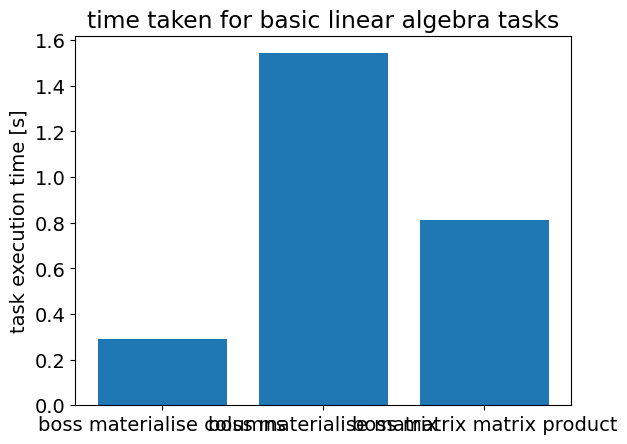

In [542]:
tasks = ['boss materialise columns', 'boss materialise matrix', 'boss matrix matrix product']
times = [rand_df.loc[5, x] / (10 ** 9) for x in tasks]

fig, ax = plt.subplots()
bar_container = ax.bar(tasks, times)
ax.set(ylabel='task execution time [s]', title='time taken for basic linear algebra tasks')

# plt.savefig(f'{diagrams_path}linear-algebra.svg', bbox_inches='tight', dpi=600)
plt.show()

In [543]:
task = 'predict duration from distance'
vendors = [
    'boss',
    'pandas',
    'duckdb',
    'sqlite',
]
bixi_full_tasks = [f'{x} {task}' for x in vendors]

loading_task = 'data in'
bixi_loading_tasks = [f'{x} {loading_task}' for x in vendors]

In [544]:
bixi_total_times = [bixi_df.loc[0, x] / (10 ** 9) for x in bixi_full_tasks]
bixi_loading_times = [bixi_df.loc[0, x] / (10 ** 9) for x in bixi_loading_tasks]
bixi_analytics_times = [bixi_total_times[i] - bixi_loading_times[i] for i in range(len(total_times))]

print('bixi_total_times')
print(bixi_total_times)
print('bixi_loading_times')
print(bixi_loading_times)
print('bixi_analytics_times')
print(bixi_analytics_times)

bixi_total_times
[1.385047755, 2.9924884745, 2.95209722825, 46.28636409633334]
bixi_loading_times
[6.1866e-05, 1.611856583857143, 1.560949031142857, 40.987593009666654]
bixi_analytics_times
[1.384985889, 1.380631890642857, 1.3911481971071429, 5.298771086666683]


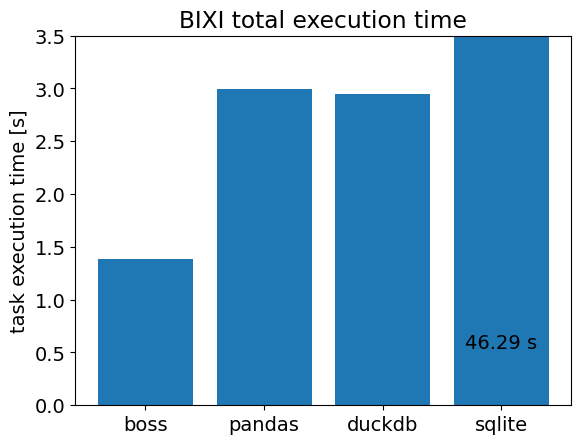

In [545]:
fig, ax = plt.subplots()
bar_container = ax.bar(vendors, bixi_total_times)
ax.set(ylabel='task execution time [s]', title='BIXI total execution time')
plt.ylim(top=3.5)

rect = bar_container[3]
ax.annotate(f'{rect.get_height():.2f} s',
            xy=(rect.get_x() + rect.get_width() / 2, 0.5),
            xytext=(0, 0),
            textcoords='offset points',
            ha='center', va='bottom')

# plt.savefig(f'{diagrams_path}bixi-total.svg', bbox_inches='tight', dpi=600)
plt.show()

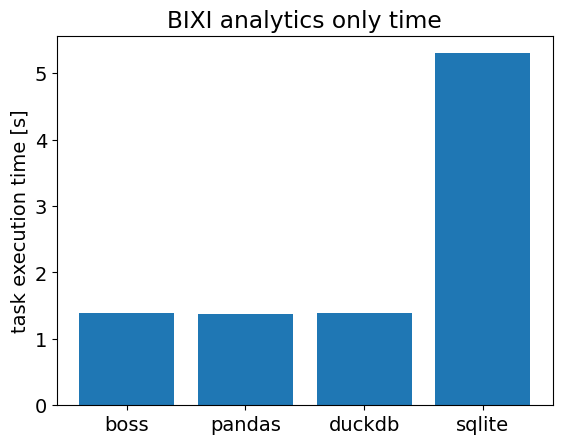

In [546]:
fig, ax = plt.subplots()
bar_container = ax.bar(vendors, bixi_analytics_times)
ax.set(ylabel='task execution time [s]', title='BIXI analytics only time')

# plt.savefig(f'{diagrams_path}bixi-analytics.svg', bbox_inches='tight', dpi=600)
plt.show()

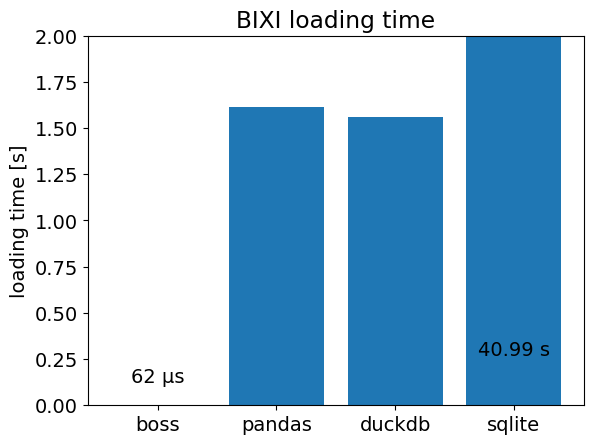

In [547]:
fig, ax = plt.subplots()
bar_container = ax.bar(vendors, bixi_loading_times)
ax.set(ylabel='loading time [s]', title='BIXI loading time')
plt.ylim(top=2)

rect = bar_container[0]
ax.annotate(f'{(rect.get_height() * (10 ** 6)):.0f} μs',
            xy=(rect.get_x() + rect.get_width() / 2, 0.1),
            xytext=(0, 0),
            textcoords='offset points',
            ha='center', va='bottom')

rect = bar_container[3]
ax.annotate(f'{rect.get_height():.2f} s',
            xy=(rect.get_x() + rect.get_width() / 2, 0.25),
            xytext=(0, 0),
            textcoords='offset points',
            ha='center', va='bottom')

# plt.savefig(f'{diagrams_path}bixi-loading.svg', bbox_inches='tight', dpi=600)
plt.show()

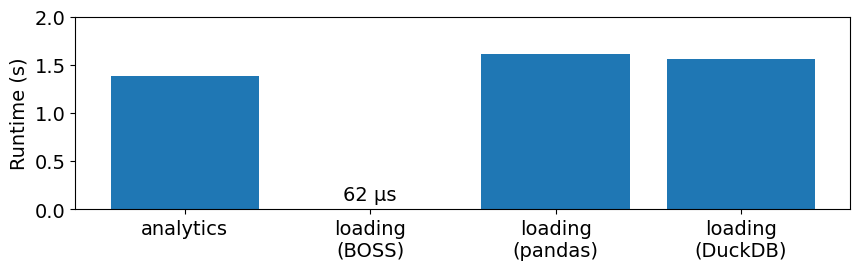

In [548]:
times = [
    1.384985889,
    6.1866e-05, 
    1.611856583857143, 
    1.560949031142857,
]

labels = [
    'analytics',
    'loading\n(BOSS)',
    'loading\n(pandas)',
    'loading\n(DuckDB)',
]

fig, ax = plt.subplots()
bar_container = ax.bar(labels, times)
ax.set(ylabel='Runtime (s)')
plt.ylim(top=2)

rect = bar_container[1]
ax.annotate(f'{(rect.get_height() * (10 ** 6)):.0f} μs',
            xy=(rect.get_x() + rect.get_width() / 2, 0.05),
            xytext=(0, 0),
            textcoords='offset points',
            ha='center', va='bottom')

figwidth = 10
aspect_ratio = (1 / 4)
fig.set_figwidth(figwidth)
fig.set_figheight(figwidth * aspect_ratio)

plt.savefig(f'{diagrams_path}bixi.svg', bbox_inches='tight', dpi=600)
plt.show()

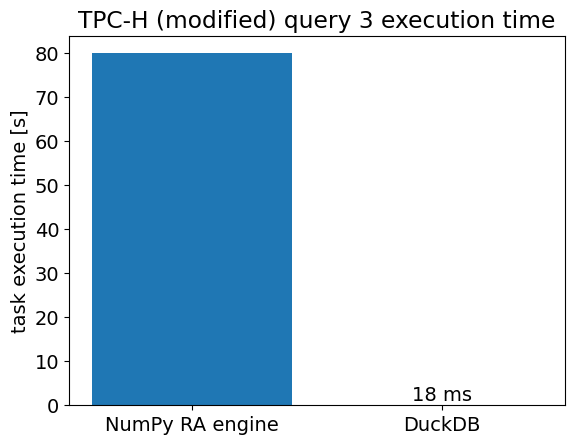

In [549]:
vendors = [
    'NumPy RA engine',
    'DuckDB',
]

times = [
    80,
    0.0179,
]

fig, ax = plt.subplots()
bar_container = ax.bar(vendors, times)
ax.set(ylabel='task execution time [s]', title='TPC-H (modified) query 3 execution time')
# ax.set_yscale('log')

rect = bar_container[1]
ax.annotate(f'{(rect.get_height() * (10 ** 3)):.0f} ms',
            xy=(rect.get_x() + rect.get_width() / 2, 0.1),
            xytext=(0, 0),
            textcoords='offset points',
            ha='center', va='bottom')

# plt.savefig(f'{diagrams_path}rel-alg-tpch-q3.svg', bbox_inches='tight', dpi=600)
plt.show()

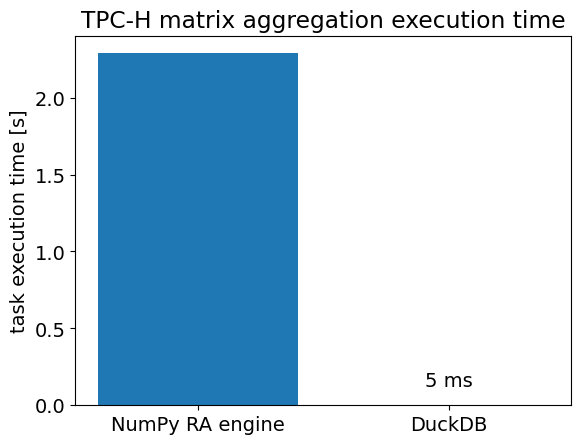

In [550]:
vendors = [
    'NumPy RA engine',
    'DuckDB',
]

times = [
    2.2884669312,
    0.0047,
]

fig, ax = plt.subplots()
bar_container = ax.bar(vendors, times)
ax.set(ylabel='task execution time [s]', title='TPC-H matrix aggregation execution time')
# ax.set_yscale('log')

rect = bar_container[1]
ax.annotate(f'{(rect.get_height() * (10 ** 3)):.0f} ms',
            xy=(rect.get_x() + rect.get_width() / 2, 0.1),
            xytext=(0, 0),
            textcoords='offset points',
            ha='center', va='bottom')

# plt.savefig(f'{diagrams_path}rel-alg-tpch-matrix-aggregation.svg', bbox_inches='tight', dpi=600)
plt.show()

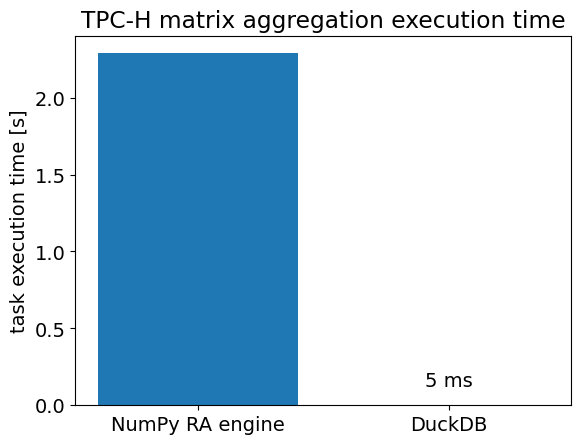

In [551]:
vendors = [
    'NumPy RA engine',
    'DuckDB',
]

times = [
    2.2884669312,
    0.0047,
]

fig, ax = plt.subplots()
bar_container = ax.bar(vendors, times)
ax.set(ylabel='task execution time [s]', title='TPC-H matrix aggregation execution time')
# ax.set_yscale('log')

rect = bar_container[1]
ax.annotate(f'{(rect.get_height() * (10 ** 3)):.0f} ms',
            xy=(rect.get_x() + rect.get_width() / 2, 0.1),
            xytext=(0, 0),
            textcoords='offset points',
            ha='center', va='bottom')

# plt.savefig(f'{diagrams_path}rel-alg-tpch-matrix-aggregation.svg', bbox_inches='tight', dpi=600)
plt.show()

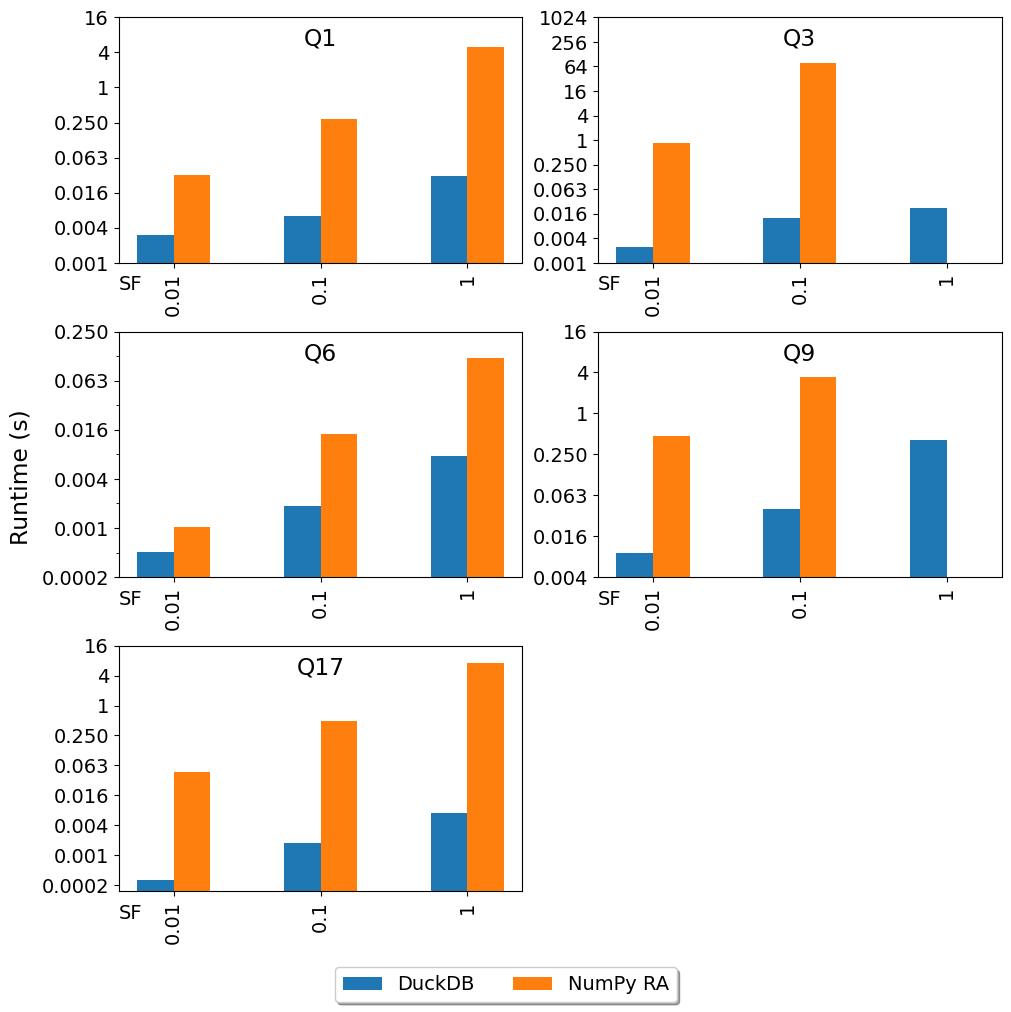

In [559]:
num_rows = 3
num_cols = 2
fig, axs = plt.subplots(num_rows, num_cols, sharex=False, sharey=False, layout="constrained")

scaling_factors = ("0.01", "0.1", "1")
vendor_times = {
    'DuckDB': np.array([
        [0.0029, 0.0061, 0.0308],
        [0.0024, 0.0123, 0.0215],
        [0.0005, 0.0018, 0.0075],
        [0.0087, 0.0386, 0.409],
        [0.0003, 0.0017, 0.0067],
    ]),
    'NumPy RA': np.array([
        [31, 289, 4995],
        [846, 78817, 0],
        [1, 14, 119],
        [457, 3438, 0],
        [46, 484, 7218],
    ]) / 1000,
}

ratio = (vendor_times['NumPy RA'] * 1000) / (vendor_times['DuckDB'] * 1000)

x = np.arange(len(scaling_factors))
width = 0.25
query_names = ['Q1', 'Q3', 'Q6', 'Q9', 'Q17']
num_elems = len(query_names)
logs = {
    -6: '0.0002', 
    -5: '0.001', 
    -4: '0.004', 
    -3: '0.016', 
    -2: '0.063', 
    -1: '0.250', 
    0: '1', 
    1: '4', 
    2: '16', 
    3: '64', 
    4: '256', 
    5: '1024',
    6: '4096',
    7: '16384',
}
logs_units = {
    -6: '0.2 ms', 
    -5: '1 ms', 
    -4: '4 ms', 
    -3: '16 ms', 
    -2: '63 ms', 
    -1: '250 ms', 
    0: '1 s', 
    1: '4 s', 
    2: '16 s', 
    3: '32 s', 
    4: '64 s', 
    5: '128 s',
}
ranges = [
    range(-5, 2 + 1),
    range(-5, 5 + 1),
    range(-6, -1 + 1),
    range(-4, 2 + 1),
    range(-6, 2 + 1),
]
major_ticks = [
    [
        4 ** x 
        for x in ranges[i]
    ] for i in range(len(ranges))
]
major_labels = [
    [
        logs[x] 
        for x in ranges[i]
    ] for i in range(len(ranges))
]
handles = []

for i in range(num_elems):
    j = i // num_cols
    k = i % num_cols
    multiplier = 0
    for attribute, measurement in vendor_times.items():
        offset = width * multiplier
        rects = axs[j, k].bar(x + offset, measurement[i], width, label=attribute)
        handles.append(rects)
        multiplier += 1
    
    axs[j, k].set_title(query_names[i], y=0.85)
    axs[j, k].set_xticks(x + width / len(vendor_times), scaling_factors)
    axs[j, k].tick_params(axis='x', labelrotation=90)
    axs[j, k].set_xlabel('SF', loc='left', y = 1.0)
    axs[j, k].xaxis.set_label_coords(0.0, -0.05)
    axs[j, k].set_yscale('log', base=4, subs=[2])
    
    axs[j, k].yaxis.set_major_locator(ticker.LogLocator(base=4))
    axs[j, k].yaxis.set_minor_locator(ticker.LogLocator(base=4, subs=[2]))
    axs[j, k].set_yticks(major_ticks[i])
    axs[j, k].set_yticklabels(major_labels[i])
    axs[j, k].yaxis.set_minor_formatter(ticker.NullFormatter())

fig.supylabel('Runtime (s)')
fig.legend(handles=handles[:2], loc='upper center', bbox_to_anchor=(0.5, -0.01),
          fancybox=True, shadow=True, ncol=2)
figwidth = 10
aspect_ratio = 1.414 * (2 / 3)
fig.set_figwidth(figwidth)
fig.set_figheight(figwidth * aspect_ratio)
fig.delaxes(axs[num_rows - 1][num_cols - 1])

plt.savefig(f'{diagrams_path}tpch-macro-absolute.svg', bbox_inches='tight', dpi=600)
plt.show()

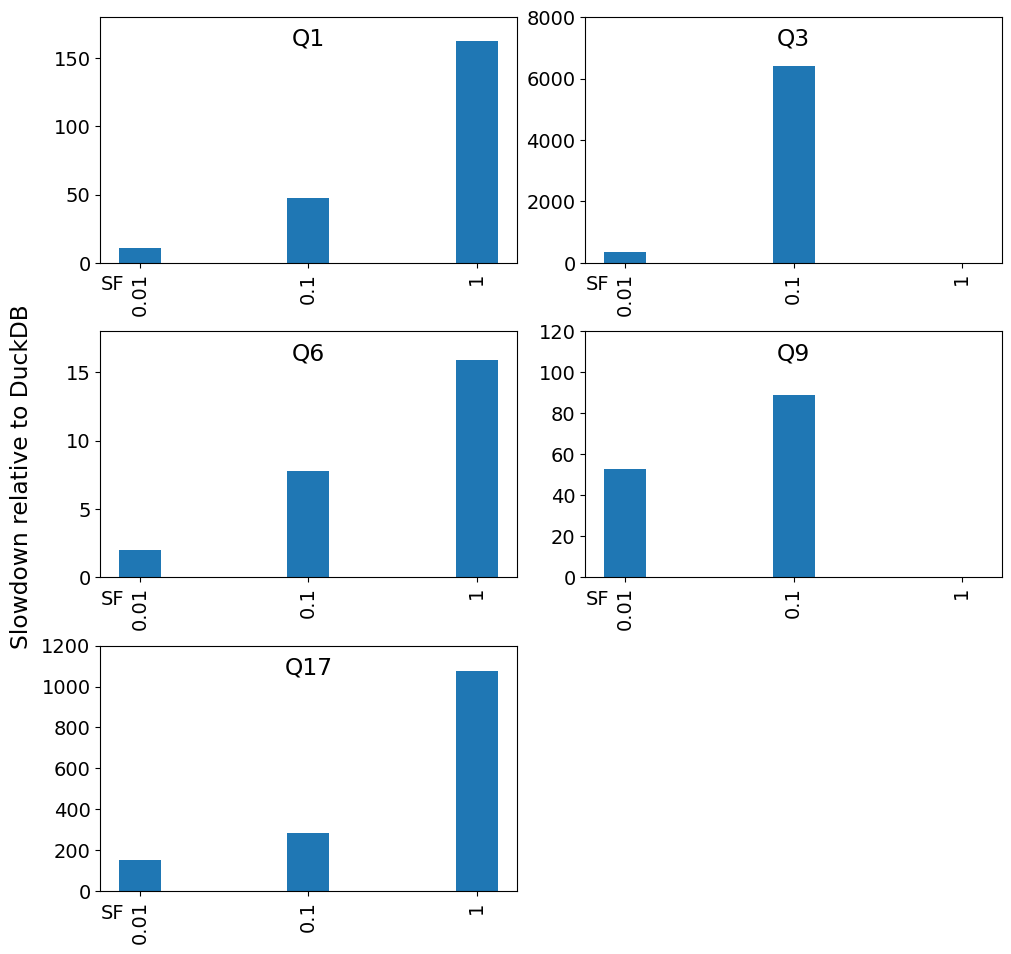

In [560]:
ylims = [
    180,
    8000,
    18,
    120,
    1200,
]

fig, axs = plt.subplots(num_rows, num_cols, sharex=False, sharey=False, layout="constrained")

for i in range(num_elems):
    j = i // num_cols
    k = i % num_cols
    rects = axs[j, k].bar(x, ratio[i], width)
    handles.append(rects)
    
    axs[j, k].set_title(query_names[i], y=0.85)
    axs[j, k].set_xticks(x, scaling_factors)
    axs[j, k].tick_params(axis='x', labelrotation=90)
    axs[j, k].set_xlabel('SF', loc='left', y = 1.0)
    axs[j, k].xaxis.set_label_coords(0.0, -0.05)
    axs[j, k].set_ylim(0, ylims[i])

fig.supylabel('Slowdown relative to DuckDB')
fig.set_figwidth(figwidth)
fig.set_figheight(figwidth * aspect_ratio)
fig.delaxes(axs[num_rows - 1][num_cols - 1])

plt.savefig(f'{diagrams_path}tpch-macro-ratio.svg', bbox_inches='tight', dpi=600)
plt.show()

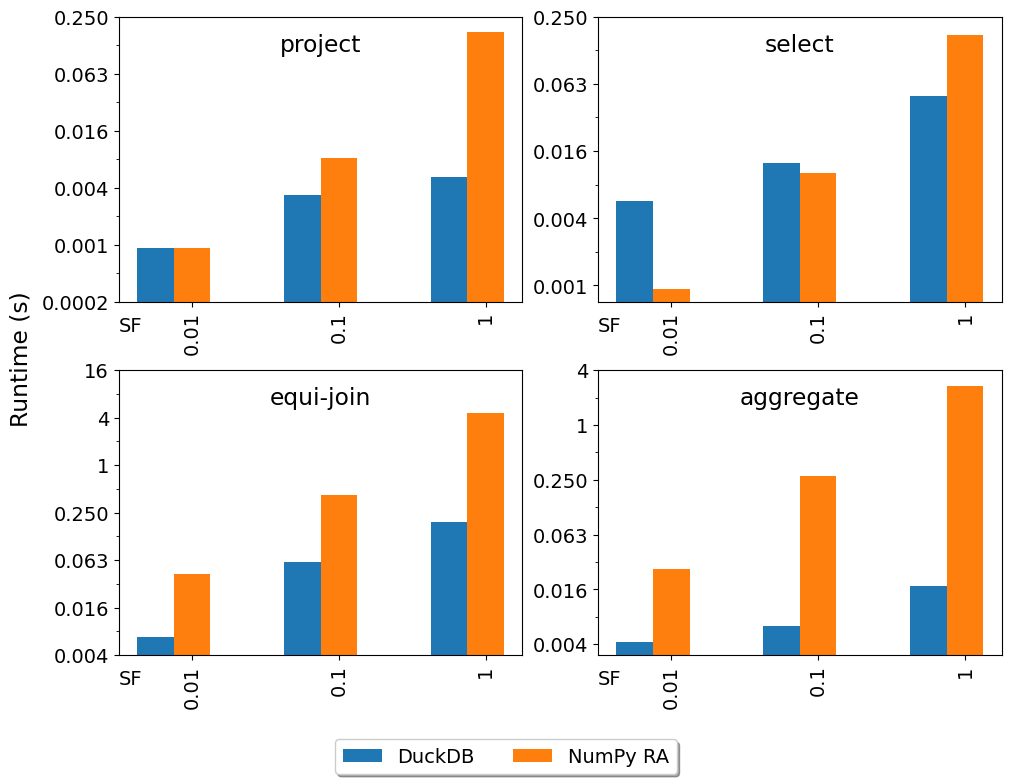

In [561]:
scaling_factors = ("0.01", "0.1", "1")
vendor_times = {
    'DuckDB': np.array([
        [0.0009, 0.0033, 0.0051],
        [0.0056, 0.0123, 0.0490],
        [0.0066, 0.0596, 0.192],
        [0.0041, 0.0062, 0.0171],
    ]),
    'NumPy RA': np.array([
        [0.89, 8, 174],
        [0.91, 10, 170],
        [42, 413, 4566],
        [26, 277, 2655],
    ]) / 1000,
}

ratio = (vendor_times['NumPy RA'] * 1000) / (vendor_times['DuckDB'] * 1000)

x = np.arange(len(scaling_factors))
width = 0.25
query_names = ['project', 'select', 'equi-join', 'aggregate']
num_elems = len(query_names)
ranges = [
    range(-6, -1 + 1),
    range(-5, -1 + 1),
    range(-4, 2 + 1),
    range(-4, 1 + 1),
]
major_ticks = [
    [
        4 ** x 
        for x in ranges[i]
    ] for i in range(len(ranges))
]
major_labels = [
    [
        logs[x] 
        for x in ranges[i]
    ] for i in range(len(ranges))
]
handles = []

num_rows = 2
num_cols = 2
fig, axs = plt.subplots(num_rows, num_cols, sharex=False, sharey=False, layout="constrained")

for i in range(num_elems):
    j = i // num_cols
    k = i % num_cols
    multiplier = 0
    for attribute, measurement in vendor_times.items():
        offset = width * multiplier
        rects = axs[j, k].bar(x + offset, measurement[i], width, label=attribute)
        handles.append(rects)
        multiplier += 1
    
    axs[j, k].set_title(query_names[i], y=0.85)
    axs[j, k].set_xticks(x + width, scaling_factors)
    axs[j, k].tick_params(axis='x', labelrotation=90)
    axs[j, k].set_xlabel('SF', loc='left', y = 1.0)
    axs[j, k].xaxis.set_label_coords(0.0, -0.05)
    axs[j, k].set_yscale('log', base=4, subs=[2])
    
    axs[j, k].yaxis.set_major_locator(ticker.LogLocator(base=4))
    axs[j, k].yaxis.set_minor_locator(ticker.LogLocator(base=4, subs=[2]))
    axs[j, k].set_yticks(major_ticks[i])
    axs[j, k].set_yticklabels(major_labels[i])
    axs[j, k].yaxis.set_minor_formatter(ticker.NullFormatter())

fig.supylabel('Runtime (s)')
fig.legend(handles=handles[:2], loc='upper center', bbox_to_anchor=(0.5, -0.025),
          fancybox=True, shadow=True, ncol=2)
aspect_ratio = 1.414 / 2
fig.set_figwidth(figwidth)
fig.set_figheight(figwidth * aspect_ratio)

plt.savefig(f'{diagrams_path}tpch-micro-absolute.svg', bbox_inches='tight', dpi=600)
plt.show()

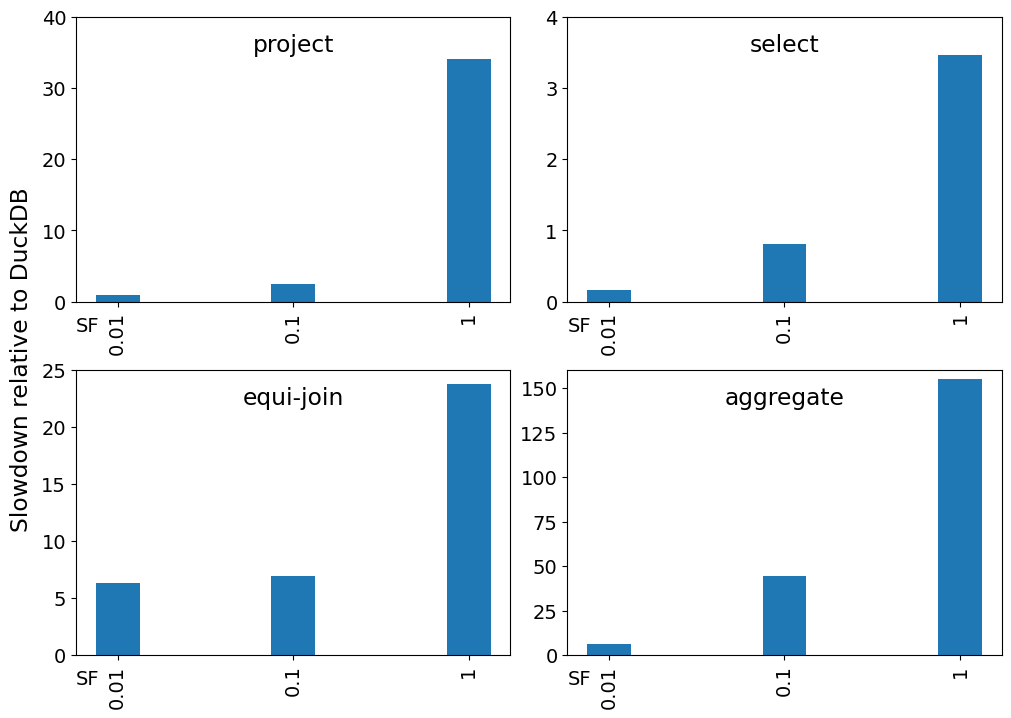

In [562]:
ylims = [
    40,
    4,
    25,
    160,
]

fig, axs = plt.subplots(num_rows, num_cols, sharex=False, sharey=False, layout="constrained")

for i in range(num_elems):
    j = i // num_cols
    k = i % num_cols
    rects = axs[j, k].bar(x, ratio[i], width)
    
    axs[j, k].set_title(query_names[i], y=0.85)
    axs[j, k].set_xticks(x, scaling_factors)
    axs[j, k].tick_params(axis='x', labelrotation=90)
    axs[j, k].set_xlabel('SF', loc='left', y = 1.0)
    axs[j, k].xaxis.set_label_coords(0.0, -0.05)
    axs[j, k].set_ylim(0, ylims[i])

fig.supylabel('Slowdown relative to DuckDB')
fig.set_figwidth(figwidth)
fig.set_figheight(figwidth * aspect_ratio)

plt.savefig(f'{diagrams_path}tpch-micro-ratio.svg', bbox_inches='tight', dpi=600)
plt.show()

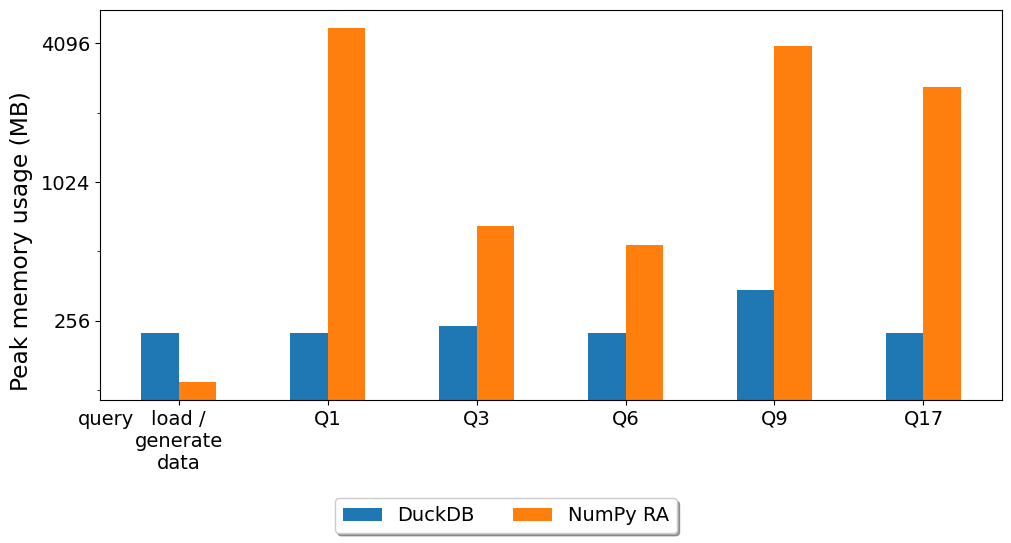

In [563]:
vendor_times = {
    'DuckDB': np.array([
        226.648,
        226.828,
        242.916,
        226.676,
        349.22,
        226.972,
    ]),
    'NumPy RA': np.array([
        138.296,
        4798.652,
        657.292,
        545.26,
        3976.32,
        2648.112,
    ]),
}

ratio = (vendor_times['NumPy RA'] * 1000) / (vendor_times['DuckDB'] * 1000)

x = np.arange(len(vendor_times['DuckDB']))
width = 0.25
query_names = ['load /\ngenerate\ndata', 'Q1', 'Q3', 'Q6', 'Q9', 'Q17']
num_elems = len(query_names)
handles = []
ranges = [range(4, 6 + 1)]
major_ticks = [
    [
        4 ** x 
        for x in ranges[i]
    ] for i in range(len(ranges))
]
major_labels = [
    [
        logs[x] 
        for x in ranges[i]
    ] for i in range(len(ranges))
]
num_rows = 1
num_cols = 1
fig, ax = plt.subplots(num_rows, num_cols, sharex=False, sharey=False, layout="constrained")

multiplier = 0
for attribute, measurement in vendor_times.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    handles.append(rects)
    multiplier += 1

# ax.set_title(query_names[i], y=0.85)
ax.set_xticks(x + width / 2, query_names)
ax.tick_params(axis='x', labelrotation=0)
ax.set_xlabel('query', loc='left', y = 1.0)
ax.xaxis.set_label_coords(-0.025, -0.025)
ax.set_yscale('log', base=4, subs=[2])

ax.yaxis.set_major_locator(ticker.LogLocator(base=4))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=4, subs=[2]))
ax.set_yticks(major_ticks[0])
ax.set_yticklabels(major_labels[0])
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    
fig.supylabel('Peak memory usage (MB)')
fig.legend(handles=handles[:2], loc='upper center', bbox_to_anchor=(0.5, -0.025),
          fancybox=True, shadow=True, ncol=2)
aspect_ratio = 1.414 / 3
fig.set_figwidth(figwidth)
fig.set_figheight(figwidth * aspect_ratio)

plt.savefig(f'{diagrams_path}tpch-macro-memory.svg', bbox_inches='tight', dpi=600)
plt.show()

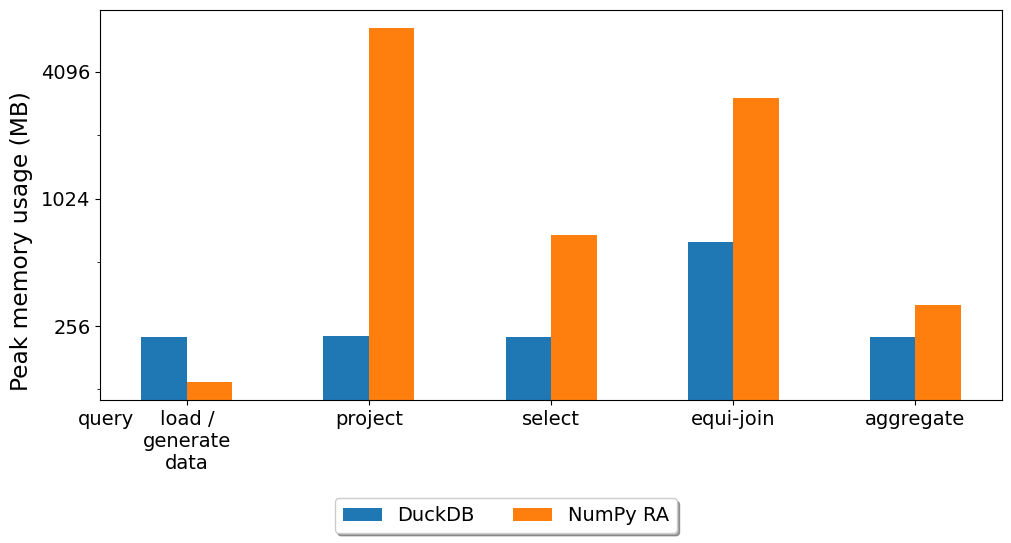

In [564]:
vendor_times = {
    'DuckDB': np.array([
        226.648,
        227.96,
        227.04,
        635.708,
        226.612,
    ]),
    'NumPy RA': np.array([
        138.296,
        6619.288,
        688.824,
        3081.0,
        321.292,
    ]),
}

ratio = (vendor_times['NumPy RA'] * 1000) / (vendor_times['DuckDB'] * 1000)

x = np.arange(len(vendor_times['DuckDB']))
width = 0.25
query_names = ['load /\ngenerate\ndata', 'project', 'select', 'equi-join', 'aggregate']
num_elems = len(query_names)
handles = []
ranges = [range(4, 6 + 1)]
major_ticks = [
    [
        4 ** x 
        for x in ranges[i]
    ] for i in range(len(ranges))
]
major_labels = [
    [
        logs[x] 
        for x in ranges[i]
    ] for i in range(len(ranges))
]
num_rows = 1
num_cols = 1
fig, ax = plt.subplots(num_rows, num_cols, sharex=False, sharey=False, layout="constrained")

multiplier = 0
for attribute, measurement in vendor_times.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    handles.append(rects)
    multiplier += 1

# ax.set_title(query_names[i], y=0.85)
ax.set_xticks(x + width / 2, query_names)
ax.tick_params(axis='x', labelrotation=0)
ax.set_xlabel('query', loc='left', y = 1.0)
ax.xaxis.set_label_coords(-0.025, -0.025)
ax.set_yscale('log', base=4, subs=[2])

ax.yaxis.set_major_locator(ticker.LogLocator(base=4))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=4, subs=[2]))
ax.set_yticks(major_ticks[0])
ax.set_yticklabels(major_labels[0])
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    
fig.supylabel('Peak memory usage (MB)')
fig.legend(handles=handles[:2], loc='upper center', bbox_to_anchor=(0.5, -0.025),
          fancybox=True, shadow=True, ncol=2)
aspect_ratio = 1.414 / 3
fig.set_figwidth(figwidth)
fig.set_figheight(figwidth * aspect_ratio)

plt.savefig(f'{diagrams_path}tpch-micro-memory.svg', bbox_inches='tight', dpi=600)
plt.show()